# 06 — Demand Forecasting

This notebook implements the **Modeling** phase of the CRISP-DM workflow for the Divvy
bike-share project. It picks up where `05_exploratory_analysis.ipynb` leaves off — using the
quality-checked warehouse from `02_database_design.ipynb` / `03_data_cleaning_and_loading.ipynb`
and validated in `04_data_quality_assessment.ipynb` — and builds a **time-series forecast of
daily ride demand**.

It answers: how many rides should we expect system-wide and per rider segment (member vs.
casual) over the next `FORECAST_HORIZON_DAYS`, and how much better is a proper time-series
model than a naive guess?

Scope: system-wide daily ride counts, plus a member/casual breakdown. ETL-flagged anomalies are
excluded, matching the population used in notebook 05. Station-level demand (for rebalancing) is
left as a follow-up notebook, since it needs a different unit of analysis (station x day) and a
much larger, sparser series per station.

### Imports, Configuration, and Helpers

In [1]:
import os
import json
import warnings
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from IPython.display import Markdown, display
import config
import cmdstanpy
cmdstanpy.install_cmdstan(overwrite=True, compiler=True)

#warnings.filterwarnings("ignore")

# Project folder (comprehensive_divvy_bike_sharing_analytics), one level up from notebooks/
PROJECT_FOLDER = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
REPORTS_FOLDER = os.path.join(PROJECT_FOLDER, "reports", "demand_forecasting_reports")
os.makedirs(REPORTS_FOLDER, exist_ok=True)

SCHEMA = "divvy"
EXCLUDE_FLAGGED_ANOMALIES = True   # matches notebook 05's population

# Forecasting configuration
TEST_HORIZON_DAYS = 28        # holdout window used to score competing models
FORECAST_HORIZON_DAYS = 28    # length of the final production forecast
SEASONAL_PERIOD = 7           # weekly seasonality (day-of-week ridership pattern)
CONFIDENCE_LEVEL = 0.80       # width of the plotted forecast interval

RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat(timespec="seconds")
print(f"Reports will be written to: {REPORTS_FOLDER}")
print(f"Run timestamp (UTC): {RUN_TIMESTAMP}")

C:\Users\shk\anaconda3\envs\machine_learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


CmdStan install directory: C:\Users\shk\.cmdstan
Installing RTools40
C++ toolchain 'RTools' version: 4.0
Install directory: C:\Users\shk\.cmdstan
Download successful, file: RTools40.exe
Installing the C++ toolchain: RTools40
RTools40.exe /SP- /SILENT /SUPPRESSMSGBOXES /CURRENTUSER LANG="English" /DIR="Users\shk\.cmdstan\RTools40" /NOICONS /NORESTART
Installed RTools40
pacman -Sy mingw-w64-x86_64-make --noconfirm


05:59:00 - cmdstanpy - INFO - Add C++ toolchain to $PATH: C:\Users\shk\.cmdstan\RTools40


Installed mingw32-make.exe
Installing CmdStan version: 2.39.0
Download successful, file: C:\Users\shk\AppData\Local\Temp\tmptjq15x4l
Extracting distribution
Unpacked download as cmdstan-2.39.0
Building version cmdstan-2.39.0, may take several minutes, depending on your system.
Installed cmdstan-2.39.0
Test model compilation
Reports will be written to: G:\My Drive\divvy_tripdata\demand_forecasting_reports
Run timestamp (UTC): 2026-08-23T11:08:55+00:00


### Database Connection

In [2]:
def run_query(sql, params=None):
    try:
        conn = psycopg2.connect(**config.config_divvy())
        return pd.read_sql_query(sql, conn, params=params)
    except Exception as error:
        raise ConnectionError(f"Could not query divvy_db: {error}") from error
    finally:
        if "conn" in locals():
            conn.close()

def savefig(filename):
    path = os.path.join(REPORTS_FOLDER, filename)
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("Saved:", path)

ANOMALY_FILTER = "COALESCE(f.is_anomalous, FALSE) = FALSE" if EXCLUDE_FLAGGED_ANOMALIES else "TRUE"
print("Population filter:", ANOMALY_FILTER)

Population filter: COALESCE(f.is_anomalous, FALSE) = FALSE


## Step 1 — Build the Daily Demand Series

Pulls one row per calendar day x rider segment from `fact_trip`/`dim_date`/`dim_member_type`,
then reindexes onto the **full** calendar range so missing days become explicit zeros instead of
silently disappearing -- a gap that would otherwise corrupt the weekly seasonality every model
below depends on.

In [3]:
daily = run_query(f'''
    SELECT d.full_date, mt.member_casual, COUNT(*) AS ride_count
    FROM {SCHEMA}.fact_trip f
    JOIN {SCHEMA}.dim_date d ON f.start_date_key = d.date_key
    JOIN {SCHEMA}.dim_member_type mt ON f.member_type_key = mt.member_type_key
    WHERE {ANOMALY_FILTER}
    GROUP BY d.full_date, mt.member_casual
    ORDER BY d.full_date
''')
daily["full_date"] = pd.to_datetime(daily["full_date"])
print(f"{len(daily):,} (date x segment) rows | {daily.full_date.min().date()} -> {daily.full_date.max().date()}")

full_range = pd.date_range(daily.full_date.min(), daily.full_date.max(), freq="D")

# System-wide series (used for the primary forecast)
system = (
    daily.groupby("full_date")["ride_count"].sum()
    .reindex(full_range, fill_value=0)
    .rename("ride_count")
)
system.index.name = "full_date"

# Member vs. casual series (used for the segment-level forecast in Step 9)
segments = (
    daily.pivot(index="full_date", columns="member_casual", values="ride_count")
    .reindex(full_range, fill_value=0)
)

n_zero_fill = int((system.reindex(full_range).fillna(0) == 0).sum())
print(f"Calendar days in series: {len(system)} | zero-ride days after gap-fill: {n_zero_fill}")
display(system.describe().to_frame("system_daily_rides"))
segments.tail()

C:\Users\shk\AppData\Local\Temp\ipykernel_456\3312801164.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


1,886 (date x segment) rows | 2024-01-01 -> 2026-07-31
Calendar days in series: 943 | zero-ride days after gap-fill: 0


,system_daily_rides
count,943.000000
mean,15291.119830
std,8569.004824
min,429.000000
25%,7594.500000
50%,15042.000000
75%,22843.500000
max,38210.000000


member_casual,casual,member
2026-07-27,4539,10900
2026-07-28,8796,18583
2026-07-29,10930,20272
2026-07-30,12587,19806
2026-07-31,11181,15047


## Step 2 — Time Series Diagnostics

Checks the assumptions each model below relies on: is the series stationary (ADF test), what
does the trend/weekly-seasonal/residual decomposition look like, and do the ACF/PACF plots
suggest the AR/MA/seasonal orders used in Step 5. This is diagnostic only -- nothing here changes
the series itself.

Augmented Dickey-Fuller: stat=-1.569, p-value=0.4994
-> non-stationary at 5%; SARIMAX's differencing (d=1) should compensate
Saved: G:\My Drive\divvy_tripdata\demand_forecasting_reports\01_decomposition.png


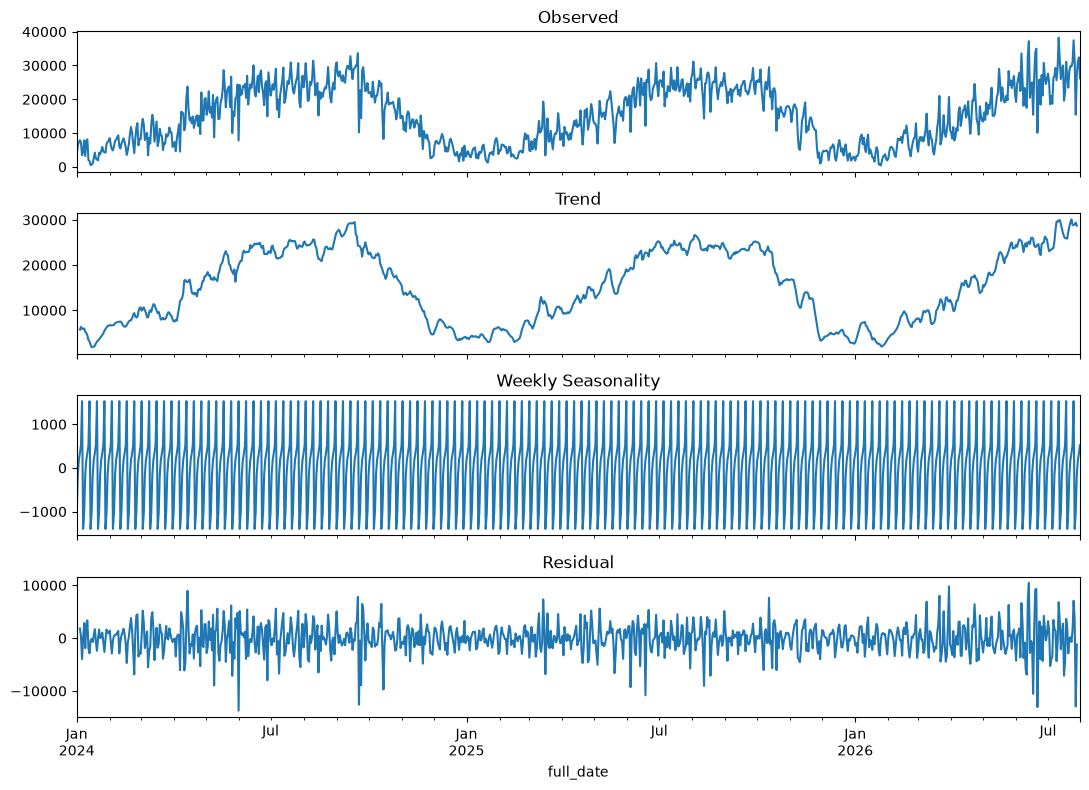

In [4]:
adf_stat, adf_p, *_ = adfuller(system.dropna())
print(f"Augmented Dickey-Fuller: stat={adf_stat:.3f}, p-value={adf_p:.4f}")
print("-> stationary (reject unit root) at 5%" if adf_p < 0.05 else "-> non-stationary at 5%; SARIMAX's differencing (d=1) should compensate")

decomposition = seasonal_decompose(system, model="additive", period=SEASONAL_PERIOD)
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Weekly Seasonality")
decomposition.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
savefig("01_decomposition.png")
plt.show()

Saved: G:\My Drive\divvy_tripdata\demand_forecasting_reports\02_acf_pacf.png


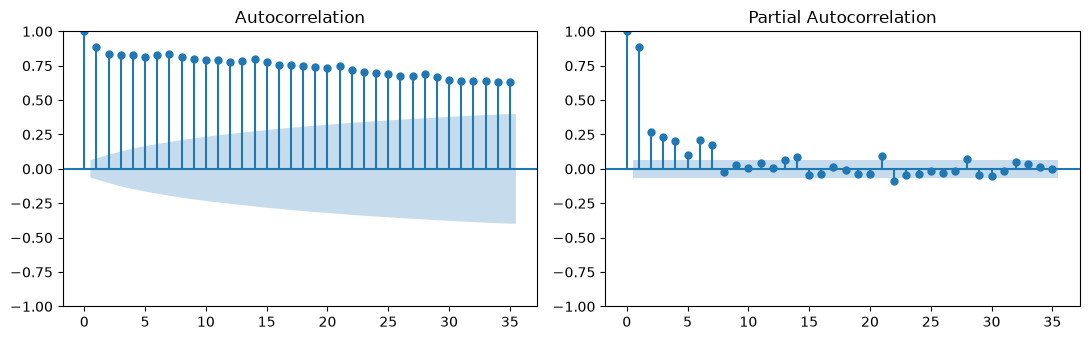

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_acf(system, lags=35, ax=axes[0])
plot_pacf(system, lags=35, ax=axes[1])
plt.tight_layout()
savefig("02_acf_pacf.png")
plt.show()

## Step 3 — Train / Test Split

Holds out the last `TEST_HORIZON_DAYS` as an out-of-sample test set. Every model in Steps 4-6 is
fit only on `train` and scored against the same `test` window, so the comparison in Step 7 is
apples-to-apples.

In [6]:
train, test = system.iloc[:-TEST_HORIZON_DAYS], system.iloc[-TEST_HORIZON_DAYS:]
print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()} ({len(test)} days)")

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else np.nan

def evaluate_forecast(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return {
        "MAE": float(np.mean(np.abs(y_true - y_pred))),
        "RMSE": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }

results = {}

Train: 2024-01-01 -> 2026-07-03 (915 days)
Test:  2026-07-04 -> 2026-07-31 (28 days)


## Step 4 — Baseline Forecasts

Two "no-model" benchmarks. Any model in Steps 5-6 that can't beat both isn't worth the added
complexity: **naive** repeats the last observed value; **seasonal naive** repeats the same
weekday from the last observed week.

In [7]:
naive_pred = np.repeat(train.iloc[-1], len(test))
results["Naive (last value)"] = evaluate_forecast(test.values, naive_pred)

last_week = train.iloc[-SEASONAL_PERIOD:].values
seasonal_naive_pred = np.tile(last_week, int(np.ceil(len(test) / SEASONAL_PERIOD)))[: len(test)]
results["Seasonal naive (last week)"] = evaluate_forecast(test.values, seasonal_naive_pred)

pd.DataFrame(results).T

,MAE,RMSE,MAPE
Naive (last value),9347.964286,10429.996533,31.738706
Seasonal naive (last week),4446.964286,5619.443322,17.219323


## Step 5 — SARIMAX Model

A SARIMAX(1,1,1)(1,1,1,7) model: first-order differencing to handle the trend flagged in Step 2,
plus a weekly seasonal term. Adjust `order`/`seasonal_order` here if your ACF/PACF plots suggest
different lags once run against your real data.

In [8]:
sarimax_fit = SARIMAX(
    train, order=(1, 1, 1), seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

sarimax_forecast = sarimax_fit.get_forecast(steps=len(test))
sarimax_mean = sarimax_forecast.predicted_mean
sarimax_ci = sarimax_forecast.conf_int(alpha=1 - CONFIDENCE_LEVEL)

results["SARIMAX"] = evaluate_forecast(test.values, sarimax_mean.values)
print(sarimax_fit.summary().tables[0])
pd.DataFrame({"SARIMAX": results["SARIMAX"]}).T

                                     SARIMAX Results                                     
Dep. Variable:                        ride_count   No. Observations:                  915
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -8561.311
Date:                           Sun, 23 Aug 2026   AIC                          17132.622
Time:                                   06:09:16   BIC                          17156.623
Sample:                               01-01-2024   HQIC                         17141.792
                                    - 07-03-2026                                         
Covariance Type:                             opg                                         


,MAE,RMSE,MAPE
SARIMAX,4115.966822,4899.365562,15.696678


## Step 6 — Prophet Model

Prophet's additive trend + weekly/yearly seasonality is a natural fit for ridership data with
holiday effects and multi-year seasonality. `yearly_seasonality` needs roughly two full years of
history to be reliable -- Prophet will warn if the loaded range is shorter; treat those forecasts
cautiously until more months are loaded.

In [9]:
prophet_train = train.reset_index().rename(columns={"full_date": "ds", "ride_count": "y"})
prophet_model = Prophet(
    weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False,
    interval_width=CONFIDENCE_LEVEL,
)
#prophet_model.fit(prophet_train)
prophet_model.fit(prophet_train, show_console=True)

future = prophet_model.make_future_dataframe(periods=len(test), freq="D")
prophet_forecast = prophet_model.predict(future)
prophet_test_pred = prophet_forecast.set_index("ds").loc[test.index, "yhat"]

results["Prophet"] = evaluate_forecast(test.values, prophet_test_pred.values)
pd.DataFrame({"Prophet": results["Prophet"]}).T

06:09:16 - cmdstanpy - INFO - Chain [1] start processing
06:09:19 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] method = optimize
Chain [1] optimize
Chain [1] algorithm = lbfgs (Default)
Chain [1] lbfgs
Chain [1] init_alpha = 0.001 (Default)
Chain [1] tol_obj = 1e-12 (Default)
Chain [1] tol_rel_obj = 10000 (Default)
Chain [1] tol_grad = 1e-08 (Default)
Chain [1] tol_rel_grad = 1e+07 (Default)
Chain [1] tol_param = 1e-08 (Default)
Chain [1] history_size = 5 (Default)
Chain [1] jacobian = false (Default)
Chain [1] iter = 10000
Chain [1] save_iterations = false (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = C:\Users\shk\AppData\Local\Temp\tmp9ru9zlxe\ekb4kos7.json
Chain [1] init = C:\Users\shk\AppData\Local\Temp\tmp9ru9zlxe\5x0p1ou9.json
Chain [1] random
Chain [1] seed = 54240
Chain [1] output
Chain [1] file = C:\Users\shk\AppData\Local\Temp\tmp9ru9zlxe\prophet_model5zaxpfnc\prophet_model-20260823060916.csv
Chain [1] diagnostic_file =  (Default)
Chain [1] refresh = 100 (Default)
Chain [1] sig_figs = 8 (Default)
Chain [1] profile_file = profile.csv (Default)
Chain [1]

,MAE,RMSE,MAPE
Prophet,4132.351933,4998.428899,15.844605


## Step 7 — Model Comparison & Selection

Ranks every model on the same held-out window by RMSE (with MAE and MAPE alongside for
context) and picks the winner used for the production forecast in Step 8.

,MAE,RMSE,MAPE
SARIMAX,4115.966822,4899.365562,15.696678
Prophet,4132.351933,4998.428899,15.844605
Seasonal naive (last week),4446.964286,5619.443322,17.219323
Naive (last value),9347.964286,10429.996533,31.738706


Best model on the 28-day holdout: SARIMAX
Saved: G:\My Drive\divvy_tripdata\demand_forecasting_reports\03_holdout_comparison.png


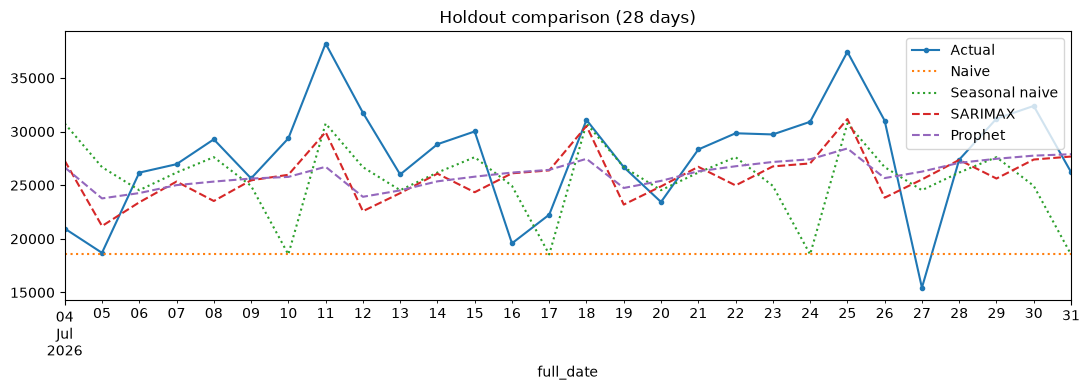

In [10]:
comparison = pd.DataFrame(results).T.sort_values("RMSE")
best_model_name = comparison.index[0]

display(comparison.style.highlight_min(subset=["MAE", "RMSE", "MAPE"], color="#d6f5d6"))
print(f"Best model on the {TEST_HORIZON_DAYS}-day holdout: {best_model_name}")

fig, ax = plt.subplots(figsize=(11, 4))
test.plot(ax=ax, label="Actual", marker="o", markersize=3)
pd.Series(naive_pred, index=test.index).plot(ax=ax, label="Naive", linestyle=":")
pd.Series(seasonal_naive_pred, index=test.index).plot(ax=ax, label="Seasonal naive", linestyle=":")
sarimax_mean.plot(ax=ax, label="SARIMAX", linestyle="--")
prophet_test_pred.plot(ax=ax, label="Prophet", linestyle="--")
ax.legend()
ax.set_title(f"Holdout comparison ({TEST_HORIZON_DAYS} days)")
plt.tight_layout()
savefig("03_holdout_comparison.png")
plt.show()

## Step 8 — Refit on Full History and Forecast Forward

Refits the winning model type on the **entire** series (train + test) -- more data, same
model -- then projects `FORECAST_HORIZON_DAYS` beyond the last loaded date with a
`CONFIDENCE_LEVEL` interval.

Saved: G:\My Drive\divvy_tripdata\demand_forecasting_reports\04_forecast.png


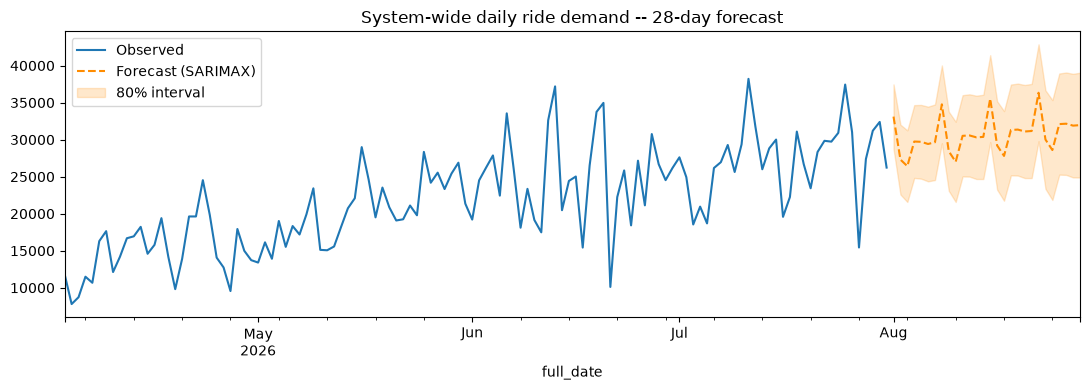

,forecast,lower,upper
2026-08-01,33111.768872,28764.555897,37458.981847
2026-08-02,27309.531522,22595.568196,32023.494848
2026-08-03,26420.935036,21583.764880,31258.105192
2026-08-04,29745.891890,24831.297293,34660.486487
2026-08-05,29708.884912,24728.669436,34689.100389


In [11]:
future_index = pd.date_range(system.index.max() + pd.Timedelta(days=1), periods=FORECAST_HORIZON_DAYS, freq="D")

if best_model_name == "SARIMAX":
    full_fit = SARIMAX(
        system, order=(1, 1, 1), seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)
    fc = full_fit.get_forecast(steps=FORECAST_HORIZON_DAYS)
    future_mean = pd.Series(fc.predicted_mean.values, index=future_index, name="forecast")
    ci = fc.conf_int(alpha=1 - CONFIDENCE_LEVEL)
    future_lower, future_upper = pd.Series(ci.iloc[:, 0].values, index=future_index), pd.Series(ci.iloc[:, 1].values, index=future_index)
    future_lower = future_lower.clip(lower=0)
elif best_model_name == "Prophet":
    full_prophet_train = system.reset_index().rename(columns={"full_date": "ds", "ride_count": "y"})
    full_prophet = Prophet(
        weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False,
        interval_width=CONFIDENCE_LEVEL,
    ).fit(full_prophet_train)
    fc_full = full_prophet.predict(full_prophet.make_future_dataframe(periods=FORECAST_HORIZON_DAYS, freq="D")).tail(FORECAST_HORIZON_DAYS)
    future_mean = pd.Series(fc_full["yhat"].values, index=future_index, name="forecast")
    future_lower = pd.Series(fc_full["yhat_lower"].values, index=future_index).clip(lower=0)
    future_upper = pd.Series(fc_full["yhat_upper"].values, index=future_index)
else:
    # Fallback: repeat the seasonal-naive pattern (only reached if a baseline wins)
    tile = np.tile(system.iloc[-SEASONAL_PERIOD:].values, int(np.ceil(FORECAST_HORIZON_DAYS / SEASONAL_PERIOD)))[:FORECAST_HORIZON_DAYS]
    future_mean = pd.Series(tile, index=future_index, name="forecast")
    future_lower = future_upper = future_mean

# Ride counts can't be negative -- clip the point forecast; the lower band is clipped above
future_mean = future_mean.clip(lower=0)

fig, ax = plt.subplots(figsize=(11, 4))
system.tail(120).plot(ax=ax, label="Observed")
future_mean.plot(ax=ax, label=f"Forecast ({best_model_name})", linestyle="--", color="darkorange")
ax.fill_between(future_index, future_lower, future_upper, color="darkorange", alpha=0.2, label=f"{int(CONFIDENCE_LEVEL*100)}% interval")
ax.legend()
ax.set_title(f"System-wide daily ride demand -- {FORECAST_HORIZON_DAYS}-day forecast")
plt.tight_layout()
savefig("04_forecast.png")
plt.show()

forecast_table = pd.DataFrame({"forecast": future_mean, "lower": future_lower, "upper": future_upper})
forecast_table.head()

## Step 9 — Segment-Level Forecast (Member vs. Casual)

Repeats the winning model type independently on the member and casual series, since the two
segments have distinct weekly patterns (commute-driven for members, leisure/weekend-driven for
casual riders, per notebook 05's findings) that a single system-wide model would blur together.

Saved: G:\My Drive\divvy_tripdata\demand_forecasting_reports\05_segment_forecast.png


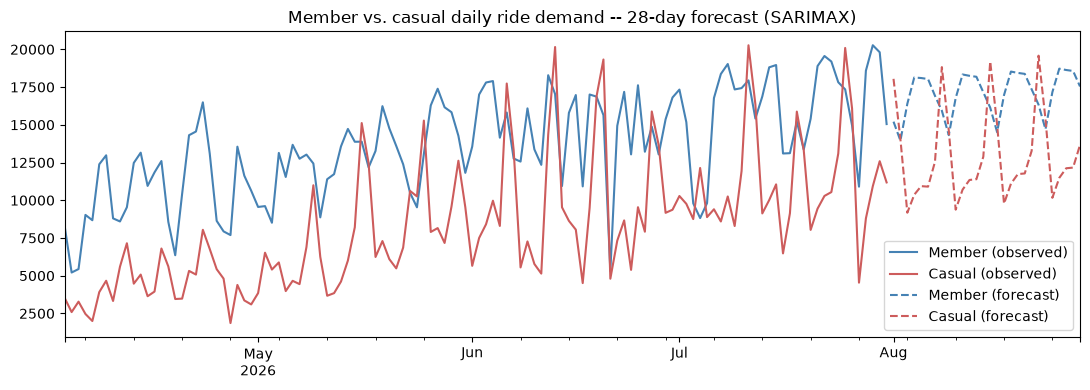

,member_forecast,casual_forecast
2026-08-01,15207.113710,18044.865871
2026-08-02,13950.771082,14031.606098
2026-08-03,16393.390679,9173.146178
2026-08-04,18133.539377,10365.651927
2026-08-05,18098.607724,10934.287048


In [12]:
def forecast_segment(series, periods, model_name):
    idx = pd.date_range(series.index.max() + pd.Timedelta(days=1), periods=periods, freq="D")
    if model_name == "SARIMAX":
        fit = SARIMAX(
            series, order=(1, 1, 1), seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        mean = pd.Series(fit.get_forecast(steps=periods).predicted_mean.values, index=idx).clip(lower=0)
    else:  # Prophet (default when a baseline wins, since baselines don't generalize to segments)
        seg_train = series.reset_index().rename(columns={series.index.name or "index": "ds", series.name: "y"})
        seg_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False,
                             interval_width=CONFIDENCE_LEVEL).fit(seg_train)
        seg_fc = seg_model.predict(seg_model.make_future_dataframe(periods=periods, freq="D")).tail(periods)
        mean = pd.Series(seg_fc["yhat"].values, index=idx)
    return mean.clip(lower=0)

segment_model = best_model_name if best_model_name in ("SARIMAX", "Prophet") else "Prophet"
member_forecast = forecast_segment(segments["member"], FORECAST_HORIZON_DAYS, segment_model)
casual_forecast = forecast_segment(segments["casual"], FORECAST_HORIZON_DAYS, segment_model)

fig, ax = plt.subplots(figsize=(11, 4))
segments["member"].tail(120).plot(ax=ax, label="Member (observed)", color="steelblue")
segments["casual"].tail(120).plot(ax=ax, label="Casual (observed)", color="indianred")
member_forecast.plot(ax=ax, label="Member (forecast)", linestyle="--", color="steelblue")
casual_forecast.plot(ax=ax, label="Casual (forecast)", linestyle="--", color="indianred")
ax.legend()
ax.set_title(f"Member vs. casual daily ride demand -- {FORECAST_HORIZON_DAYS}-day forecast ({segment_model})")
plt.tight_layout()
savefig("05_segment_forecast.png")
plt.show()

segment_forecast_table = pd.DataFrame({"member_forecast": member_forecast, "casual_forecast": casual_forecast})
segment_forecast_table.head()

## Step 10 — Forecast Report

Writes the holdout comparison, the chosen model, and the production forecast to disk in three
formats -- Markdown for a human-readable summary, JSON for the full detail, and CSV for
spreadsheet/BI consumption (e.g. as a Power BI data source) -- mirroring notebook 04's report
pattern.

In [13]:
report = {
    "run_timestamp_utc": RUN_TIMESTAMP,
    "series_range": {"start": str(system.index.min().date()), "end": str(system.index.max().date())},
    "test_horizon_days": TEST_HORIZON_DAYS,
    "forecast_horizon_days": FORECAST_HORIZON_DAYS,
    "holdout_comparison": comparison.to_dict(orient="index"),
    "best_model": best_model_name,
    "confidence_level": CONFIDENCE_LEVEL,
    "system_forecast": forecast_table.reset_index().rename(columns={"index": "date"}).assign(date=lambda d: d["date"].astype(str)).to_dict(orient="records"),
    "segment_model": segment_model,
    "segment_forecast": segment_forecast_table.reset_index().rename(columns={"index": "date"}).assign(date=lambda d: d["date"].astype(str)).to_dict(orient="records"),
}

md_lines = [
    "# Divvy Demand Forecast Report",
    f"**Run timestamp (UTC):** {RUN_TIMESTAMP}  ",
    f"**Series range:** {report['series_range']['start']} -> {report['series_range']['end']}  ",
    f"**Best model ({TEST_HORIZON_DAYS}-day holdout):** {best_model_name}\n",
    "## Holdout Comparison",
    comparison.to_markdown(),
    f"\n## {FORECAST_HORIZON_DAYS}-Day System-Wide Forecast (first 7 days)",
    forecast_table.head(7).to_markdown(),
    f"\n## {FORECAST_HORIZON_DAYS}-Day Segment Forecast (first 7 days, model: {segment_model})",
    segment_forecast_table.head(7).to_markdown(),
]
report_md = "\n\n".join(md_lines)

md_path = os.path.join(REPORTS_FOLDER, "demand_forecast_report.md")
json_path = os.path.join(REPORTS_FOLDER, "demand_forecast_report.json")
csv_path = os.path.join(REPORTS_FOLDER, "demand_forecast.csv")

with open(md_path, "w", encoding="utf-8") as fh:
    fh.write(report_md)
with open(json_path, "w", encoding="utf-8") as fh:
    json.dump(report, fh, indent=2, default=str)
forecast_table.join(segment_forecast_table).reset_index().rename(columns={"index": "date"}).to_csv(csv_path, index=False)

print(f"Markdown report : {md_path}")
print(f"JSON report     : {json_path}")
print(f"CSV forecast    : {csv_path}")
print(f"Charts          : {REPORTS_FOLDER}")

Markdown report : G:\My Drive\divvy_tripdata\demand_forecasting_reports\demand_forecast_report.md
JSON report     : G:\My Drive\divvy_tripdata\demand_forecasting_reports\demand_forecast_report.json
CSV forecast    : G:\My Drive\divvy_tripdata\demand_forecasting_reports\demand_forecast.csv
Charts          : G:\My Drive\divvy_tripdata\demand_forecasting_reports


## Summary

This notebook closes the CRISP-DM **Modeling** phase: it benchmarked two naive baselines against
SARIMAX and Prophet on a held-out window, selected the stronger model by RMSE/MAE/MAPE, and used
it to produce both a system-wide and a member/casual demand forecast with uncertainty intervals.

Interpretation notes: MAPE is unstable on near-zero-demand days (e.g. deep winter), so weight MAE
and RMSE more heavily when the series has a strong seasonal trough. A widening forecast interval
over the horizon is expected and reflects growing uncertainty, not a modeling error. The
member/casual split should be read alongside notebook 05's seasonality findings -- casual demand
is far more weather/weekend-sensitive, so its forecast will carry a wider interval than member
demand.

Next steps (CRISP-DM Evaluation / Deployment):
- Re-run this notebook after every ETL load (`03_data_cleaning_and_loading.ipynb`) to track
  whether forecast accuracy holds as more months are loaded, and to extend Prophet's yearly
  seasonality estimate once 2+ years of history are available.
- If the business question shifts from *how many rides* to *who will ride* (e.g. predicting
  membership conversion), that's a separate classification notebook on `fact_trip`/`dim_member_type`
  rather than a change to this one.
- For deployment, the CSV/JSON outputs here are already shaped to feed a Power BI forecast page
  or a scheduled job that re-scores the model and alerts on demand spikes above the operational
  capacity used for bike rebalancing.